In [1]:
import torch

import triton
import triton.language as tl

DEVICE = triton.runtime.driver.active.get_active_torch_device()

In [2]:
@triton.autotune(
    configs=[
        triton.Config({'BLOCK_SIZE': 256},  num_warps=2, num_stages=2),
        triton.Config({'BLOCK_SIZE': 256},  num_warps=4, num_stages=3),
        triton.Config({'BLOCK_SIZE': 512},  num_warps=4, num_stages=2),
        triton.Config({'BLOCK_SIZE': 512},  num_warps=4, num_stages=4),
        triton.Config({'BLOCK_SIZE': 1024}, num_warps=4, num_stages=3),
        triton.Config({'BLOCK_SIZE': 1024}, num_warps=8, num_stages=4),
        triton.Config({'BLOCK_SIZE': 2048}, num_warps=8, num_stages=3),
        triton.Config({'BLOCK_SIZE': 2048}, num_warps=8, num_stages=5),
    ],
    key=['n_elements'],
)
@triton.jit
def add_kernel(x_ptr,
               y_ptr,
               out_ptr,
               n_elements,
               BLOCK_SIZE: tl.constexpr):
    pid = tl.program_id(0)

    offsets = pid * BLOCK_SIZE + tl.arange(0, BLOCK_SIZE)
    mask = offsets < n_elements

    x = tl.load(x_ptr + offsets, mask=mask)
    y = tl.load(y_ptr + offsets, mask=mask)

    tl.store(out_ptr + offsets, x + y, mask=mask)

In [3]:
def add(x: torch.Tensor, y: torch.Tensor):
    output = torch.empty_like(x)
    n_elements = output.numel()

    grid = lambda meta: (triton.cdiv(n_elements, meta['BLOCK_SIZE']),)
    add_kernel[grid](x, y, output, n_elements)

    return output

In [4]:
torch.manual_seed(0)
size = 2**20

x = torch.rand(size, device="cuda")
y = torch.rand(size, device="cuda")

output_torch = x + y
output_triton = add(x, y)

print(output_torch)
print(output_triton)

print(torch.max(torch.abs(output_torch - output_triton)))

tensor([0.4185, 1.2900, 0.8900,  ..., 0.4743, 0.3000, 0.7694], device='cuda:0')
tensor([0.4185, 1.2900, 0.8900,  ..., 0.4743, 0.3000, 0.7694], device='cuda:0')
tensor(0., device='cuda:0')


In [5]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],
        x_vals=[2**i for i in range(12, 28)],
        x_log=True,
        line_arg='provider',
        line_vals=['triton', 'torch'],
        line_names=['triton', 'torch'],
        styles=[('red', '--'), ('blue', '--')],
        ylabel='GB per second',
        plot_name='vector-addition',
        args={},
    ))
def benchmark(size, provider):
    x = torch.rand(size, device=DEVICE, dtype=torch.float32)
    y = torch.rand(size, device=DEVICE, dtype=torch.float32)

    fn = (lambda: x + y) if provider == 'torch' else (lambda: add(x, y))
    ms, min_ms, max_ms = triton.testing.do_bench(fn, quantiles=[0.5, 0.2, 0.8])

    gbps = lambda ms: 3 * x.numel() * x.element_size() / ms * 1e-6
    return gbps(ms), gbps(max_ms), gbps(min_ms)

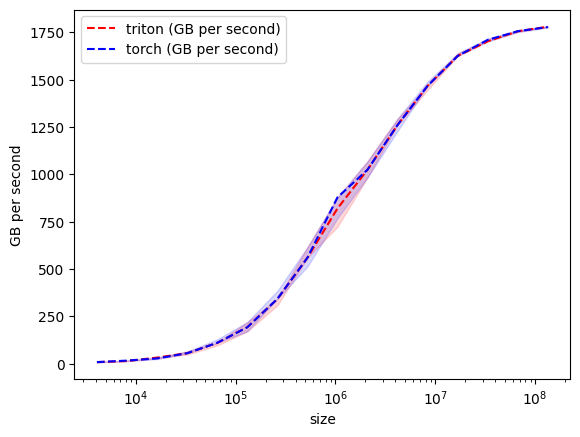

vector-addition:
           size  triton (GB per second)  torch (GB per second)
0        4096.0                8.000000               8.000000
1        8192.0               13.714286              15.999999
2       16384.0               31.999999              27.428571
3       32768.0               54.857142              54.857142
4       65536.0              109.714284             109.714284
5      131072.0              192.000000             192.000000
6      262144.0              341.333321             341.333321
7      524288.0              558.545450             558.545450
8     1048576.0              819.200021             877.714274
9     2097152.0             1023.999964            1023.999964
10    4194304.0             1260.307736            1260.307736
11    8388608.0             1467.223862            1467.223862
12   16777216.0             1624.859540            1624.859540
13   33554432.0             1702.233780            1709.634745
14   67108864.0             1755.42854

In [6]:
benchmark.run(print_data=True, show_plots=True)